# **DEFINISI FUNGSI MODULAR**

---



## Setup MNIST

In [ ]:
def setup_mnist_environment(model_name):
    """
    Menangani mounting drive, setup path, dan inisialisasi DataLoaders.
    """
    from google.colab import drive
    import os
    from torchvision import datasets, transforms
    from torch.utils.data import DataLoader

    # 1. Mount Drive (hanya jika belum di-mount)
    drive.mount('/content/drive', force_remount=True)

    # 2. Setup Paths
    model_dir = '/content/drive/MyDrive/model_modular'
    os.makedirs(model_dir, exist_ok=True)
    path = os.path.join(model_dir, model_name)

    # 3. DataLoaders
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)) # Standard normalization for MNIST
    ])

    train_set = datasets.MNIST(root='./data_mnist', train=True, download=True, transform=transform)
    test_set = datasets.MNIST(root='./data_mnist', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)

    return path, train_loader, test_loader

## Load or Training Model & Eval Model

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

def evaluate_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def load_and_prepare_model(model_class, model_path, train_loader, test_loader, device, num_epochs=10, lr=0.001):
    model = model_class().to(device)
    history = {'loss': [], 'accuracy': []}

    if os.path.exists(model_path):
        print(f"✅ Loading existing model from {model_path}...")
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        history = checkpoint.get('history', history)
        print(f"✅ Model loaded. Previous accuracy: {history['accuracy'][-1]:.2f}%" if history['accuracy'] else "✅ Model loaded.")
    else:
        print(f"❌ No model found at {model_path}. Starting training...")
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0
            for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

            acc = evaluate_accuracy(model, test_loader, device)
            avg_loss = running_loss / len(train_loader)
            history['loss'].append(avg_loss)
            history['accuracy'].append(acc)
            print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {acc:.2f}%")

        print(f"💾 Saving model to {model_path}...")
        torch.save({'model_state_dict': model.state_dict(), 'history': history}, model_path)
        print("✅ Training complete and model saved.")

    return model, history

print("✅ Unified Model Manager & Trainer defined!")

✅ Unified Model Manager & Trainer defined!


## Fungsi Kuantisasi Modular

Standard & Fine-Grained Quantization Ternary


In [ ]:
import torch
import torch.nn as nn
import copy
import numpy as np

def standard_ternary_quantize(weight_tensor):
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()
    abs_weights = torch.abs(flat_weights)
    if abs_weights.max().item() == 0:
        return torch.zeros_like(weight_tensor), 0.0
    delta = 0.7 * torch.mean(abs_weights)
    mask = abs_weights > delta
    if mask.sum() == 0:
        return torch.zeros_like(weight_tensor), 0.0
    alpha = abs_weights[mask].sum() / mask.sum().float()
    ternary_flat = torch.zeros_like(flat_weights)
    ternary_flat[flat_weights > delta] = alpha
    ternary_flat[flat_weights < -delta] = -alpha
    return ternary_flat.reshape(original_shape), alpha.item()

def apply_standard_ternary_to_model(model, verbose=False):
    model_q = copy.deepcopy(model)
    layer_alphas = []
    for name, module in model_q.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            ternary_weight, alpha = standard_ternary_quantize(module.weight.data)
            module.weight.data = ternary_weight
            layer_alphas.append(alpha)
            if verbose: print(f"  ✓ {name}: quantized with ́={alpha:.4f}")
    return model_q, layer_alphas

def ternary_quantize_group(weight_tensor, group_size=4, asymmetric=False):
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()
    n = flat_weights.numel()
    ternary_flat = torch.zeros_like(flat_weights)
    alphas = []

    for i in range(0, n, group_size):
        group = flat_weights[i:min(i+group_size, n)]
        if len(group) == 0: continue

        if not asymmetric:
            abs_group = torch.abs(group)
            if abs_group.max().item() == 0:
                alphas.append(0.0)
                continue
            thresholds = torch.linspace(abs_group.min().item(), abs_group.max().item(), steps=20)
            best_delta, best_score = 0, -float('inf')
            for delta in thresholds:
                mask = abs_group > delta
                if mask.sum() == 0: continue
                score = (abs_group[mask].sum() ** 2) / mask.sum().float()
                if score > best_score: best_score, best_delta = score, delta

            mask = abs_group > best_delta
            if mask.sum() == 0:
                alphas.append(0.0)
                continue
            alpha = abs_group[mask].sum() / mask.sum().float()
            alphas.append(alpha.item())
            ternary_group = torch.zeros_like(group)
            ternary_group[group > best_delta] = alpha
            ternary_group[group < -best_delta] = -alpha
        else:
            # Asymmetric logic: Separate delta and alpha for positive and negative values
            pos_mask = group > 0
            neg_mask = group < 0

            a_pos, a_neg = 0.0, 0.0
            d_pos, d_neg = 0.0, 0.0

            if pos_mask.any():
                pos_vals = group[pos_mask]
                d_pos = 0.7 * torch.mean(pos_vals)
                m_pos = pos_vals > d_pos
                if m_pos.any(): a_pos = torch.mean(pos_vals[m_pos])

            if neg_mask.any():
                neg_vals = group[neg_mask]
                d_neg = 0.7 * torch.mean(torch.abs(neg_vals))
                m_neg = torch.abs(neg_vals) > d_neg
                if m_neg.any(): a_neg = torch.mean(neg_vals[m_neg])

            ternary_group = torch.zeros_like(group)
            ternary_group[group > d_pos] = a_pos
            ternary_group[group < -d_neg] = a_neg
            alphas.append((abs(a_pos) + abs(a_neg)).item() / 2.0 if torch.is_tensor(a_pos) else (abs(a_pos) + abs(a_neg)) / 2.0)

        ternary_flat[i:min(i+group_size, n)] = ternary_group

    return ternary_flat.reshape(original_shape), alphas

def apply_fgq_to_model(model, group_size=4, asymmetric=False, verbose=False):
    if isinstance(group_size, (list, set, tuple)):
        results = {}
        for gs in sorted(list(group_size)):
            if verbose: print(f"\n--- Processing Group Size: {gs} (Asymmetric={asymmetric}) ---")
            m_q, a_m = apply_fgq_to_model(model, gs, asymmetric, verbose)
            results[gs] = (m_q, a_m)
        return results

    model_q = copy.deepcopy(model)
    all_alpha_means = []
    for name, module in model_q.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            ternary_weight, alphas = ternary_quantize_group(module.weight.data, group_size, asymmetric)
            module.weight.data = ternary_weight
            m_alpha = np.mean(alphas) if alphas else 0
            all_alpha_means.append(m_alpha)
            if verbose: print(f"  ✓ {name}: FGQ N={group_size}, Asym={asymmetric}, mean_́={m_alpha:.4f}")
    return model_q, all_alpha_means

def find_best_fgq_model(fgq_results, test_loader, device):
    best_acc = -1.0
    best_gs = None
    best_model = None

    print("\n--- Evaluating All Group Sizes ---")
    for gs, (model_q, _) in fgq_results.items():
        acc = evaluate_accuracy(model_q, test_loader, device)
        print(f"Group Size {gs}: Accuracy = {acc:.2f}%")
        if acc > best_acc:
            best_acc = acc
            best_gs = gs
            best_model = model_q

    print(f"\n✅ Best Result: Group Size {best_gs} with Accuracy {best_acc:.2f}%")
    return best_gs, best_model, best_acc

## Definisi Model

### LeNet-5

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Redefine Model Class
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = x.view(-1, 16 * 5 * 5)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 2. Re-initialize DataLoader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Standard normalization for MNIST
])

test_dataset = datasets.MNIST(root='./data_mnist', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# 3. Instantiate model and define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LeNet5().to(device)

print("✅ Setup for verification complete: Model and Test Loader are ready.")

✅ Setup for verification complete: Model and Test Loader are ready.


### ResNet-18

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Redefine Model Class for ResNet18
class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        # Load a pre-trained ResNet18 model
        self.model = models.resnet18(weights=None) # weights=None to avoid downloading ImageNet weights for now

        # Modify the first convolution layer for single-channel input (MNIST images are grayscale)
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Modify the final fully connected layer to match the number of classes (MNIST has 10 classes)
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.model(x)

# Instantiate model and define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNet18().to(device)

print("✅ ResNet18 model defined and ready for MNIST.")

✅ ResNet18 model defined and ready for MNIST.


# **PENGUJIAN TRAINING & KUANTISASI**

---



## Model Setup

#### ResNet-18

In [ ]:
# 1. Siapkan environment (Drive, Path, Data)
# Perbaikan: Fungsi setup_mnist_environment sekarang mengecek status mount
model_path_resnet, train_loader_resnet, test_loader_resnet = setup_mnist_environment('resnet18_mnist_baseline.pth')

# 2. Panggil manager model
model_fp32_resnet, history_resnet = load_and_prepare_model(
    ResNet18,
    model_path_resnet,
    train_loader_resnet,
    test_loader_resnet,
    device,
    num_epochs=5
)

print(f"\nProses selesai. Akurasi Baseline: {history_resnet['accuracy'][-1]:.2f}%")

Mounted at /content/drive
✅ Loading existing model from /content/drive/MyDrive/model_modular/resnet18_mnist_baseline.pth...
✅ Model loaded. Previous accuracy: 98.82%

Proses selesai. Akurasi Baseline: 98.82%


#### LeNet-5

In [ ]:
# 1. Siapkan environment (Drive, Path, Data)
model_path_lenet, train_loader_lenet, test_loader_lenet = setup_mnist_environment('lenet5_mnist_baseline.pth')

# 2. Panggil manager model
model_fp32_lenet, history_lenet = load_and_prepare_model(
    LeNet5,
    model_path_lenet,
    train_loader_lenet,
    test_loader_lenet,
    device,
    num_epochs=5
)

print(f"\nProses selesai. Akurasi Baseline: {history_lenet['accuracy'][-1]:.2f}%")

Mounted at /content/drive
✅ Loading existing model from /content/drive/MyDrive/model_modular/lenet5_mnist_baseline.pth...
✅ Model loaded. Previous accuracy: 98.89%

Proses selesai. Akurasi Baseline: 98.89%


## Kuantisasi Model

### *Standard Ternary Quantization*

#### ResNet-18

In [ ]:
model_ternary_resnet, alphas_resnet = apply_standard_ternary_to_model(model_fp32_resnet, verbose=True)
acc_ternary_resnet = evaluate_accuracy(model_ternary_resnet, test_loader, device)

print(f"Baseline: {history_resnet['accuracy'][-1]:.2f}%")
print(f"Ternary: {acc_ternary_resnet:.2f}%")

  ✓ model.conv1: quantized with ́=0.1045
  ✓ model.layer1.0.conv1: quantized with ́=0.0786
  ✓ model.layer1.0.conv2: quantized with ́=0.0778
  ✓ model.layer1.1.conv1: quantized with ́=0.0778
  ✓ model.layer1.1.conv2: quantized with ́=0.0775
  ✓ model.layer2.0.conv1: quantized with ́=0.0577
  ✓ model.layer2.0.conv2: quantized with ́=0.0572
  ✓ model.layer2.0.downsample.0: quantized with ́=0.1521
  ✓ model.layer2.1.conv1: quantized with ́=0.0559
  ✓ model.layer2.1.conv2: quantized with ́=0.0554
  ✓ model.layer3.0.conv1: quantized with ́=0.0407
  ✓ model.layer3.0.conv2: quantized with ́=0.0386
  ✓ model.layer3.0.downsample.0: quantized with ́=0.1097
  ✓ model.layer3.1.conv1: quantized with ́=0.0368
  ✓ model.layer3.1.conv2: quantized with ́=0.0369
  ✓ model.layer4.0.conv1: quantized with ́=0.0271
  ✓ model.layer4.0.conv2: quantized with ́=0.0255
  ✓ model.layer4.0.downsample.0: quantized with ́=0.0779
  ✓ model.layer4.1.conv1: quantized with ́=0.0252
  ✓ model.layer4.1.conv2: quantized wi

#### LeNet-5

In [ ]:
model_ternary_lenet, alphas_lenet = apply_standard_ternary_to_model(model_fp32_lenet, verbose=True)
acc_ternary_lenet = evaluate_accuracy(model_ternary_lenet, test_loader, device)

print(f"Baseline: {history_lenet['accuracy'][-1]:.2f}%")
print(f"Ternary: {acc_ternary_lenet:.2f}%")

  ✓ conv1: quantized with ́=0.2316
  ✓ conv2: quantized with ́=0.1280
  ✓ fc1: quantized with ́=0.0676
  ✓ fc2: quantized with ́=0.0841
  ✓ fc3: quantized with ́=0.1122
Baseline: 98.89%
Ternary: 94.18%


### *Fine-Grained Ternary Quantization*

#### ResNet-18

In [ ]:
fgq_results_resnet = apply_fgq_to_model(model_fp32_resnet, group_size={4, 8, 16}, asymmetric=True, verbose=True)

best_gs_resnet, best_model_fgq_resnet, best_acc_resnet = find_best_fgq_model(fgq_results_resnet, test_loader_resnet, device)

print(f"\nBaseline Accuracy: {history_resnet['accuracy'][-1]:.2f}%")
print(f"Akurasi Terbaik ditemukan pada Group Size {best_gs_resnet}: {best_acc_resnet:.2f}%")


--- Processing Group Size: 4 (Asymmetric=True) ---
  ✓ model.conv1: FGQ N=4, Asym=True, mean_́=0.0855
  ✓ model.layer1.0.conv1: FGQ N=4, Asym=True, mean_́=0.0628
  ✓ model.layer1.0.conv2: FGQ N=4, Asym=True, mean_́=0.0619
  ✓ model.layer1.1.conv1: FGQ N=4, Asym=True, mean_́=0.0621
  ✓ model.layer1.1.conv2: FGQ N=4, Asym=True, mean_́=0.0619
  ✓ model.layer2.0.conv1: FGQ N=4, Asym=True, mean_́=0.0458
  ✓ model.layer2.0.conv2: FGQ N=4, Asym=True, mean_́=0.0464
  ✓ model.layer2.0.downsample.0: FGQ N=4, Asym=True, mean_́=0.1237
  ✓ model.layer2.1.conv1: FGQ N=4, Asym=True, mean_́=0.0453
  ✓ model.layer2.1.conv2: FGQ N=4, Asym=True, mean_́=0.0448
  ✓ model.layer3.0.conv1: FGQ N=4, Asym=True, mean_́=0.0328
  ✓ model.layer3.0.conv2: FGQ N=4, Asym=True, mean_́=0.0314
  ✓ model.layer3.0.downsample.0: FGQ N=4, Asym=True, mean_́=0.0889
  ✓ model.layer3.1.conv1: FGQ N=4, Asym=True, mean_́=0.0300
  ✓ model.layer3.1.conv2: FGQ N=4, Asym=True, mean_́=0.0301
  ✓ model.layer4.0.conv1: FGQ N=4, Asym=Tru

#### LeNet-5

In [ ]:
fgq_results_lenet = apply_fgq_to_model(model_fp32_lenet, group_size={4, 8, 16}, asymmetric=True, verbose=True)

best_gs_lenet, best_model_fgq_lenet, best_acc_lenet = find_best_fgq_model(fgq_results_lenet, test_loader, device)

print(f"\nBaseline Accuracy: {history_lenet['accuracy'][-1]:.2f}%")
print(f"Akurasi Terbaik ditemukan pada Group Size {best_gs_lenet}: {best_acc_lenet:.2f}%")


--- Processing Group Size: 4 (Asymmetric=True) ---
  ✓ conv1: FGQ N=4, Asym=True, mean_́=0.1777
  ✓ conv2: FGQ N=4, Asym=True, mean_́=0.0854
  ✓ fc1: FGQ N=4, Asym=True, mean_́=0.0496
  ✓ fc2: FGQ N=4, Asym=True, mean_́=0.0678
  ✓ fc3: FGQ N=4, Asym=True, mean_́=0.0906

--- Processing Group Size: 8 (Asymmetric=True) ---
  ✓ conv1: FGQ N=8, Asym=True, mean_́=0.1959
  ✓ conv2: FGQ N=8, Asym=True, mean_́=0.1003
  ✓ fc1: FGQ N=8, Asym=True, mean_́=0.0590
  ✓ fc2: FGQ N=8, Asym=True, mean_́=0.0791
  ✓ fc3: FGQ N=8, Asym=True, mean_́=0.1062

--- Processing Group Size: 16 (Asymmetric=True) ---
  ✓ conv1: FGQ N=16, Asym=True, mean_́=0.2127
  ✓ conv2: FGQ N=16, Asym=True, mean_́=0.1123
  ✓ fc1: FGQ N=16, Asym=True, mean_́=0.0637
  ✓ fc2: FGQ N=16, Asym=True, mean_́=0.0811
  ✓ fc3: FGQ N=16, Asym=True, mean_́=0.1095

--- Evaluating All Group Sizes ---
Group Size 4: Accuracy = 98.69%
Group Size 8: Accuracy = 98.43%
Group Size 16: Accuracy = 98.04%

✅ Best Result: Group Size 4 with Accuracy 98.69

## Perbandingan Akurasi

### ResNet18

In [ ]:
print(f"Baseline: {history_resnet['accuracy'][-1]:.2f}%")
print(f"Ternary: {acc_ternary_resnet:.2f}%")
print(f"FGQ best Group Size: {best_acc_resnet:.2f}%")

Baseline: 98.82%
Ternary: 23.41%
FGQ best Group Size: 98.02%


### Lenet5

In [ ]:
print(f"Baseline: {history_lenet['accuracy'][-1]:.2f}%")
print(f"Ternary: {acc_ternary_lenet:.2f}%")
print(f"FGQ best Group Size: {best_acc_lenet:.2f}%")

Baseline: 98.89%
Ternary: 94.18%
FGQ best Group Size: 98.69%


## Penyimpanan Model Kuantisasi

In [ ]:
import torch
import os
import copy
import json
from safetensors.torch import save_file, load_file

def pack_2bit(mask):
    """Pack 4 ternary values into 1 byte (using 0, 1, 2 mapping)"""
    flat = mask.flatten().to(torch.uint8)
    n = flat.numel()
    pad = (4 - (n % 4)) % 4
    if pad > 0:
        flat = torch.cat([flat, torch.zeros(pad, dtype=torch.uint8)])

    # Reshape to (N/4, 4) and pack
    grouped = flat.view(-1, 4)
    packed = (grouped[:, 0] & 3) | ((grouped[:, 1] & 3) << 2) | ((grouped[:, 2] & 3) << 4) | ((grouped[:, 3] & 3) << 6)
    return packed, mask.shape

def unpack_2bit(packed, shape, numel):
    """Unpack uint8 back to ternary mask"""
    unpacked = torch.zeros(packed.numel(), 4, dtype=torch.uint8, device=packed.device)
    unpacked[:, 0] = packed & 3
    unpacked[:, 1] = (packed >> 2) & 3
    unpacked[:, 2] = (packed >> 4) & 3
    unpacked[:, 3] = (packed >> 6) & 3

    mask = unpacked.flatten()[:numel].reshape(shape)
    return mask.to(torch.int8)

def save_ternary_safetensors(model, alphas=None, group_size=None, path='model.safetensors'):
    tensors = {}
    meta_list = []

    for name, module in model.named_modules():
        # --- BatchNorm ---
        if isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
            tensors[f"{name}.weight"] = module.weight.data.clone()
            tensors[f"{name}.bias"] = module.bias.data.clone()
            tensors[f"{name}.running_mean"] = module.running_mean.clone()
            tensors[f"{name}.running_var"] = module.running_var.clone()
            meta_list.append({"n": name, "type": "bn"})
            continue

        # --- Conv2d / Linear ---
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            w = module.weight.data
            # Buat mask ternary: 0=negatif, 1=no1, 2=positif
            m = torch.zeros_like(w, dtype=torch.int8)
            m[w < 0] = 0
            m[w == 0] = 1
            m[w > 0] = 2

            packed, original_shape = pack_2bit(m)
            tensors[f"{name}.p"] = packed

            info = {
                "n": name,
                "type": "linear",
                "s": list(original_shape),
                "num": w.numel(),
                "has_bias": module.bias is not None
            }

            if module.bias is not None:
                tensors[f"{name}.bias"] = module.bias.data.clone()

            # --- Penanganan Alpha ---
            if alphas is not None:
                # Standard Ternary: satu alpha per layer
                linear_count = len([m for m in meta_list if m.get("type") == "linear"])
                info["a"] = float(alphas[linear_count]) if linear_count < len(alphas) else 1.0
            else:
                # FGQ Asimetris: simpan alpha per group dalam satu tensor (N, 2)
                gs = group_size or 4
                info["gs"] = gs
                flat_w = w.flatten()
                alpha_pairs = []
                for i in range(0, flat_w.numel(), gs):
                    g = flat_w[i:i+gs]
                    pos_vals = g[g > 0]
                    neg_vals = g[g < 0]
                    a_pos = pos_vals.mean().item() if pos_vals.numel() > 0 else 0.0
                    a_neg = neg_vals.mean().item() if neg_vals.numel() > 0 else 0.0
                    alpha_pairs.append([a_pos, a_neg])
                tensors[f"{name}.alpha"] = torch.tensor(alpha_pairs, dtype=torch.float32)  # shape (num_groups, 2)

            meta_list.append(info)

    save_file(tensors, path, metadata={"config": json.dumps(meta_list)})
    print(f"✅ Saved: {path}")

def load_ternary_safetensors(path, template_model):
    from safetensors import safe_open

    tensors = load_file(path)
    with safe_open(path, framework="pt") as f:
        meta_list = json.loads(f.metadata()["config"])

    # Buat salinan model template
    model = copy.deepcopy(template_model)
    state_dict = model.state_dict()

    for info in meta_list:
        name = info["n"]

        # --- BatchNorm ---
        if info.get("type") == "bn":
            state_dict[f"{name}.weight"] = tensors[f"{name}.weight"]
            state_dict[f"{name}.bias"] = tensors[f"{name}.bias"]
            state_dict[f"{name}.running_mean"] = tensors[f"{name}.running_mean"]
            state_dict[f"{name}.running_var"] = tensors[f"{name}.running_var"]
            continue

        # --- Conv2d / Linear ---
        packed = tensors[f"{name}.p"]
        mask = unpack_2bit(packed, info["s"], info["num"])

        # Rekonstruksi bobot dasar (-1, 0, +1)
        w_rec = torch.zeros(info["num"], dtype=torch.float32)
        mask_flat = mask.flatten()
        w_rec[mask_flat == 0] = -1.0
        w_rec[mask_flat == 1] = 0.0
        w_rec[mask_flat == 2] = 1.0

        # --- Terapkan Alpha ---
        if "a" in info:
            # Standard Ternary
            w_rec *= info["a"]
        elif "gs" in info:
            # FGQ Asimetris: alpha per group (tensor (num_groups, 2))
            gs = info["gs"]
            alpha = tensors[f"{name}.alpha"]  # shape (num_groups, 2)
            for i in range(alpha.shape[0]):
                start = i * gs
                end = min(start + gs, info["num"])
                segment = w_rec[start:end]
                # Terapkan alpha positif (kolom 0) ke nilai > 0
                segment[segment > 0] = alpha[i, 0]
                # Terapkan alpha negatif (kolom 1) ke nilai < 0
                segment[segment < 0] = alpha[i, 1]
                w_rec[start:end] = segment

        # Update weight
        state_dict[f"{name}.weight"] = w_rec.reshape(info["s"])

        # Update bias jika ada
        if info.get("has_bias", False) and f"{name}.bias" in tensors:
            state_dict[f"{name}.bias"] = tensors[f"{name}.bias"]

    model.load_state_dict(state_dict)
    return model

### **Eksekusi Penyimpanan Model ke Safetensors**

In [ ]:
import os

# 1. Pastikan variabel FGQ tersedia
if 'best_model_fgq_resnet' not in locals():
    print("ⅴ Menghitung ulang FGQ ResNet...")
    fgq_results_resnet = apply_fgq_to_model(model_fp32_resnet, group_size={4}, asymmetric=True)
    best_gs_resnet, best_model_fgq_resnet, best_acc_resnet = find_best_fgq_model(fgq_results_resnet, test_loader_resnet, device)

if 'best_model_fgq_lenet' not in locals():
    print("ⅴ Menghitung ulang FGQ LeNet...")
    fgq_results_lenet = apply_fgq_to_model(model_fp32_lenet, group_size={4}, asymmetric=True)
    best_gs_lenet, best_model_fgq_lenet, best_acc_lenet = find_best_fgq_model(fgq_results_lenet, test_loader_lenet, device)

# 2. Tentukan folder penyimpanan
save_dir = '/content/drive/MyDrive/model_modular/safetensors_models'
os.makedirs(save_dir, exist_ok=True)

# 3. Simpan ResNet-18
save_ternary_safetensors(model_ternary_resnet, alphas=alphas_resnet, path=os.path.join(save_dir, 'resnet18_standard.safetensors'))
save_ternary_safetensors(best_model_fgq_resnet, group_size=best_gs_resnet, path=os.path.join(save_dir, 'resnet18_fgq.safetensors'))

# 4. Simpan LeNet-5
save_ternary_safetensors(model_ternary_lenet, alphas=alphas_lenet, path=os.path.join(save_dir, 'lenet5_standard.safetensors'))
save_ternary_safetensors(best_model_fgq_lenet, group_size=best_gs_lenet, path=os.path.join(save_dir, 'lenet5_fgq.safetensors'))

print("\n✅ Semua model berhasil disimpan ke Safetensors!")

✅ Saved: /content/drive/MyDrive/model_modular/safetensors_models/resnet18_standard.safetensors
✅ Saved: /content/drive/MyDrive/model_modular/safetensors_models/resnet18_fgq.safetensors
✅ Saved: /content/drive/MyDrive/model_modular/safetensors_models/lenet5_standard.safetensors
✅ Saved: /content/drive/MyDrive/model_modular/safetensors_models/lenet5_fgq.safetensors

✅ Semua model berhasil disimpan ke Safetensors!


### **Verifikasi Pemuatan (Load) dari Safetensors**

In [ ]:
import os

def verify_all_safetensors(save_dir, device):
    model_configs = [
        {'name': 'ResNet-18 Standard', 'file': 'resnet18_standard.safetensors', 'class': ResNet18, 'loader': test_loader_resnet, 'target': acc_ternary_resnet},
        {'name': 'ResNet-18 FGQ',      'file': 'resnet18_fgq.safetensors',      'class': ResNet18, 'loader': test_loader_resnet, 'target': best_acc_resnet},
        {'name': 'LeNet-5 Standard',   'file': 'lenet5_standard.safetensors',   'class': LeNet5,   'loader': test_loader_lenet,  'target': acc_ternary_lenet},
        {'name': 'LeNet-5 FGQ',        'file': 'lenet5_fgq.safetensors',        'class': LeNet5,   'loader': test_loader_lenet,  'target': best_acc_lenet},
    ]

    print(f"{'Model Name':<20} | {'Loaded Acc':<12} | {'Target Acc':<12} | {'Status'}")
    print("-" * 65)

    for cfg in model_configs:
        path = os.path.join(save_dir, cfg['file'])
        if not os.path.exists(path):
            print(f"❌ File not found: {cfg['file']}")
            continue

        # Load model
        model = load_ternary_safetensors(path, cfg['class']()).to(device)

        # Evaluasi
        acc = evaluate_accuracy(model, cfg['loader'], device)

        status = "✅ MATCH" if abs(acc - cfg['target']) < 0.01 else "⚠️ MISMATCH"
        print(f"{cfg['name']:<20} | {acc:>10.2f}% | {cfg['target']:>10.2f}% | {status}")

# Eksekusi Verifikasi
verify_all_safetensors(save_dir, device)

Model Name           | Loaded Acc   | Target Acc   | Status
-----------------------------------------------------------------
ResNet-18 Standard   |      23.41% |      23.41% | ✅ MATCH
ResNet-18 FGQ        |      98.02% |      98.02% | ✅ MATCH
LeNet-5 Standard     |      94.18% |      94.18% | ✅ MATCH
LeNet-5 FGQ          |      98.69% |      98.69% | ✅ MATCH


In [ ]:
import os
import torch

# 1. Tentukan path file model yang ingin dievaluasi
file_name = 'lenet5_standard.safetensors'
model_path = os.path.join(save_dir, file_name)

# 2. Pastikan file ada sebelum memuat
if os.path.exists(model_path):
    print(f"🔄 Memuat model: {file_name}...")

    # Gunakan template ResNet18 karena file tersebut adalah model ResNet
    # Pastikan variabel 'device' dan 'test_loader_resnet' sudah terdefinisi dari sel sebelumnya
    loaded_model = load_ternary_safetensors(model_path, LeNet5()).to(device)

    # 3. Jalankan Evaluasi
    print(f"⌛ Menghitung akurasi pada dataset test...")
    accuracy = evaluate_accuracy(loaded_model, test_loader_resnet, device)

    print(f"\n✅ Hasil Evaluasi untuk {file_name}:")
    print(f"Akurasi: {accuracy:.2f}%")
else:
    print(f"❌ File tidak ditemukan di: {model_path}")

🔄 Memuat model: lenet5_standard.safetensors...
⌛ Menghitung akurasi pada dataset test...

✅ Hasil Evaluasi untuk lenet5_standard.safetensors:
Akurasi: 94.18%


In [ ]:
train_set = datasets.MNIST(root='./data_mnist', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data_mnist', train=False, download=True, transform=transform)

# Menghitung ukuran dataset MNIST test set dalam memori
num_samples = len(train_set)
data_shape = train_set[0][0].shape
element_size = train_set[0][0].element_size() # ukuran per elemen dalam byte (biasanya float32 = 4 bytes)

# Total bytes = jumlah_sampel * (elemen_per_citra * byte_per_elemen)
total_bytes = num_samples * train_set[0][0].nelement() * element_size

size_kb = total_bytes / 1024
size_mb = size_kb / 1024
size_gb = size_mb / 1024

print(f"--- Ukuran Dataset Test (MNIST) ---")
print(f"Jumlah Sampel: {num_samples}")
print(f"Dimensi Citra: {list(data_shape)}")
print(f"Ukuran Total: {total_bytes:,} Bytes")
print(f"Ukuran Total: {size_mb:.2f} MB")
print(f"Ukuran Total: {size_gb:.4f} GB")

--- Ukuran Dataset Test (MNIST) ---
Jumlah Sampel: 60000
Dimensi Citra: [1, 28, 28]
Ukuran Total: 188,160,000 Bytes
Ukuran Total: 179.44 MB
Ukuran Total: 0.1752 GB


# **INFERENSI**

---

### ResNet-18

⌂ Memuat baseline dari: resnet18_mnist_baseline.pth
⌂ Memuat kuantisasi dari: resnet18_standard.safetensors

⌂ Mengunggah gambar untuk inferensi & benchmark...


Saving angka-4.jpg to angka-4 (9).jpg

      PERBANDINGAN INFERENSI
╣ Baseline (FP32): 4 (89.0%) | 9.205 ms | 108.6 FPS
╣ Kuantisasi FGQ: 1 (81.4%) | 9.026 ms | 110.8 FPS
⚡ Speedup: 1.02x

⎈ Citra Input (28x28):


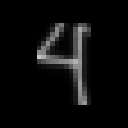

In [ ]:
import torch
import time
import numpy as np
from PIL import Image, ImageEnhance, ImageOps, ImageFilter
from google.colab import files
import os

# === PENGATURAN PATH MODEL ===
# Tentukan path model (sesuaikan jika direktori Anda berbeda)
base_dir = '/content/drive/MyDrive/model_modular'
baseline_path = os.path.join(base_dir, 'resnet18_mnist_baseline.pth')
quantized_path = os.path.join(base_dir, 'safetensors_models', 'resnet18_standard.safetensors')

# Memuat model berdasarkan path yang ditentukan
# Catatan: Kita asumsikan arsitekturnya adalah ResNet18 sesuai contoh path Anda
print(f"\u2302 Memuat baseline dari: {os.path.basename(baseline_path)}")
model_baseline = ResNet18().to(device)
checkpoint = torch.load(baseline_path, map_location=device)
model_baseline.load_state_dict(checkpoint['model_state_dict'])

print(f"\u2302 Memuat kuantisasi dari: {os.path.basename(quantized_path)}")
model_quant = load_ternary_safetensors(quantized_path, ResNet18()).to(device)
# =============================

def preprocess_final_v3_fixed(path, invert=True):
    img = Image.open(path).convert('L')
    if invert: img = ImageOps.invert(img)
    img = img.point(lambda p: 255 if p > 128 else 0)
    img = img.filter(ImageFilter.MaxFilter(3))
    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)
    w, h = img.size
    ratio = 18.0 / max(w, h)
    new_size = (int(w * ratio), int(h * ratio))
    img = img.resize(new_size, Image.Resampling.LANCZOS)
    img = img.filter(ImageFilter.GaussianBlur(radius=0.6))
    final_img = Image.new('L', (28, 28), 0)
    final_img.paste(img, (int((28 - new_size[0]) / 2), int((28 - new_size[1]) / 2)))
    img_array = np.array(final_img, dtype=np.float32) / 255.0
    img_tensor = (img_array - 0.1307) / 0.3081
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0)
    return img_tensor.to(device), final_img

def benchmark_inference(model, tensor, num_runs=100):
    model.eval()
    for _ in range(10): # Warmup
        with torch.no_grad():
            _ = model(tensor)
    if device.type == 'cuda': torch.cuda.synchronize()
    start = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(tensor)
    if device.type == 'cuda': torch.cuda.synchronize()
    end = time.time()
    avg_ms = ((end - start) / num_runs) * 1000
    fps = 1000 / avg_ms
    return avg_ms, fps

print("\n\u2302 Mengunggah gambar untuk inferensi & benchmark...")
uploaded = files.upload()
if uploaded:
    image_path = list(uploaded.keys())[0]
    input_tensor, processed_img = preprocess_final_v3_fixed(image_path, invert=True)

    # Jalankan Benchmark & Prediksi
    t_base, fps_base = benchmark_inference(model_baseline, input_tensor)
    with torch.no_grad():
        out_b = model_baseline(input_tensor)
        p_base = out_b.argmax().item()
        c_base = torch.nn.functional.softmax(out_b, dim=1)[0][p_base].item() * 100

    t_quant, fps_quant = benchmark_inference(model_quant, input_tensor)
    with torch.no_grad():
        out_q = model_quant(input_tensor)
        p_quant = out_q.argmax().item()
        c_quant = torch.nn.functional.softmax(out_q, dim=1)[0][p_quant].item() * 100

    print("\n" + "="*50)
    print(f"      PERBANDINGAN INFERENSI")
    print("="*50)
    print(f"\u2563 Baseline (FP32): {p_base} ({c_base:.1f}%) | {t_base:.3f} ms | {fps_base:.1f} FPS")
    print(f"\u2563 Kuantisasi FGQ: {p_quant} ({c_quant:.1f}%) | {t_quant:.3f} ms | {fps_quant:.1f} FPS")
    print("="*50)
    speedup = t_base / t_quant
    print(f"\u26a1 Speedup: {speedup:.2f}x")

    from IPython.display import display
    print("\n\u2388 Citra Input (28x28):")
    display(processed_img.resize((128, 128), Image.Resampling.NEAREST))

### LeNet-5

⌂ Memuat baseline dari: lenet5_mnist_baseline.pth
⌂ Memuat kuantisasi dari: lenet5_standard.safetensors

⌂ Mengunggah gambar untuk inferensi & benchmark...


Saving angka-4.jpg to angka-4 (10).jpg

      PERBANDINGAN INFERENSI
╣ Baseline (FP32): 4 (74.7%) | 0.469 ms | 2131.3 FPS
╣ Kuantisasi FGQ: 4 (25.1%) | 0.447 ms | 2237.0 FPS
⚡ Speedup: 1.05x

⎈ Citra Input (28x28):


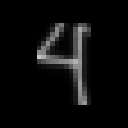

In [ ]:
import torch
import time
import numpy as np
from PIL import Image, ImageEnhance, ImageOps, ImageFilter
from google.colab import files
import os

# === PENGATURAN PATH MODEL ===
# Tentukan path model (sesuaikan jika direktori Anda berbeda)
base_dir = '/content/drive/MyDrive/model_modular'
baseline_path = os.path.join(base_dir, 'lenet5_mnist_baseline.pth')
quantized_path = os.path.join(base_dir, 'safetensors_models', 'lenet5_standard.safetensors')

# Memuat model berdasarkan path yang ditentukan
# Catatan: Kita asumsikan arsitekturnya adalah LeNet5 sesuai contoh path Anda
print(f"\u2302 Memuat baseline dari: {os.path.basename(baseline_path)}")
model_baseline = LeNet5().to(device)
checkpoint = torch.load(baseline_path, map_location=device)
model_baseline.load_state_dict(checkpoint['model_state_dict'])

print(f"\u2302 Memuat kuantisasi dari: {os.path.basename(quantized_path)}")
model_quant = load_ternary_safetensors(quantized_path, LeNet5()).to(device)
# =============================

def preprocess_final_v3_fixed(path, invert=True):
    img = Image.open(path).convert('L')
    if invert: img = ImageOps.invert(img)
    img = img.point(lambda p: 255 if p > 128 else 0)
    img = img.filter(ImageFilter.MaxFilter(3))
    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)
    w, h = img.size
    ratio = 18.0 / max(w, h)
    new_size = (int(w * ratio), int(h * ratio))
    img = img.resize(new_size, Image.Resampling.LANCZOS)
    img = img.filter(ImageFilter.GaussianBlur(radius=0.6))
    final_img = Image.new('L', (28, 28), 0)
    final_img.paste(img, (int((28 - new_size[0]) / 2), int((28 - new_size[1]) / 2)))
    img_array = np.array(final_img, dtype=np.float32) / 255.0
    img_tensor = (img_array - 0.1307) / 0.3081
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0)
    return img_tensor.to(device), final_img

def benchmark_inference(model, tensor, num_runs=100):
    model.eval()
    for _ in range(10): # Warmup
        with torch.no_grad():
            _ = model(tensor)
    if device.type == 'cuda': torch.cuda.synchronize()
    start = time.time()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(tensor)
    if device.type == 'cuda': torch.cuda.synchronize()
    end = time.time()
    avg_ms = ((end - start) / num_runs) * 1000
    fps = 1000 / avg_ms
    return avg_ms, fps

print("\n\u2302 Mengunggah gambar untuk inferensi & benchmark...")
uploaded = files.upload()
if uploaded:
    image_path = list(uploaded.keys())[0]
    input_tensor, processed_img = preprocess_final_v3_fixed(image_path, invert=True)

    # Jalankan Benchmark & Prediksi
    t_base, fps_base = benchmark_inference(model_baseline, input_tensor)
    with torch.no_grad():
        out_b = model_baseline(input_tensor)
        p_base = out_b.argmax().item()
        c_base = torch.nn.functional.softmax(out_b, dim=1)[0][p_base].item() * 100

    t_quant, fps_quant = benchmark_inference(model_quant, input_tensor)
    with torch.no_grad():
        out_q = model_quant(input_tensor)
        p_quant = out_q.argmax().item()
        c_quant = torch.nn.functional.softmax(out_q, dim=1)[0][p_quant].item() * 100

    print("\n" + "="*50)
    print(f"      PERBANDINGAN INFERENSI")
    print("="*50)
    print(f"\u2563 Baseline (FP32): {p_base} ({c_base:.1f}%) | {t_base:.3f} ms | {fps_base:.1f} FPS")
    print(f"\u2563 Kuantisasi FGQ: {p_quant} ({c_quant:.1f}%) | {t_quant:.3f} ms | {fps_quant:.1f} FPS")
    print("="*50)
    speedup = t_base / t_quant
    print(f"\u26a1 Speedup: {speedup:.2f}x")

    from IPython.display import display
    print("\n\u2388 Citra Input (28x28):")
    display(processed_img.resize((128, 128), Image.Resampling.NEAREST))